In [136]:
import torch
import torch.nn as nn

In [137]:
#hyperparameters
lr = 1e-5
epochs=40
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dropout = 0.1

In [138]:
class LeNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv_layer = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5),
        nn.BatchNorm2d(6),
        nn.Tanh(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(6, 16, kernel_size=5),
        nn.BatchNorm2d(16),
        nn.Tanh(),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )
    self.flatten = nn.Flatten()
    self.fc = nn.Sequential(
        nn.Linear(400,120),
        nn.Tanh(),
        nn.Linear(120,84),
        nn.Tanh(),
        nn.Linear(84,10)
    )
    self.dropout = nn.Dropout(dropout)

  def forward(self, x):
    x = self.conv_layer(x)
    x = self.flatten(x)
    x = self.fc(x)
    x = self.dropout(x)
    return x



In [139]:
model = LeNet().to(device)
dummy = torch.randn(1,1,32,32).to(device)
out = model(dummy)
out.shape


torch.Size([1, 10])

In [140]:
from torchvision import datasets
from torchvision.transforms import transforms

train_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

val_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST(root='/content/data', train=True, download=True, transform=train_transform)
test_dataset = datasets.MNIST(root='/content/data', train=False, download=True, transform=val_transform)

Label: 5
Tensor shape: torch.Size([1, 32, 32])


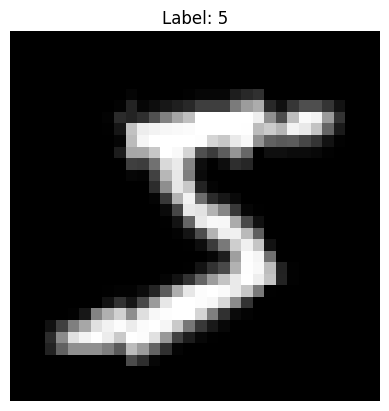

Label: 0
Tensor shape: torch.Size([1, 32, 32])


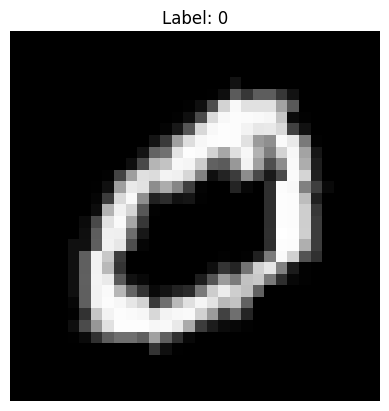

Label: 4
Tensor shape: torch.Size([1, 32, 32])


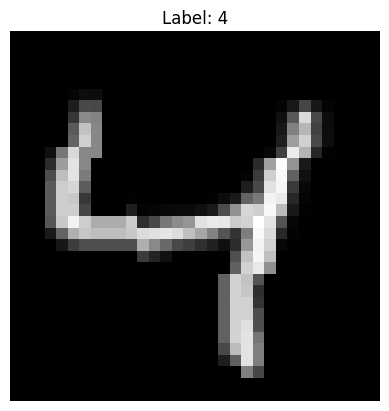

Label: 1
Tensor shape: torch.Size([1, 32, 32])


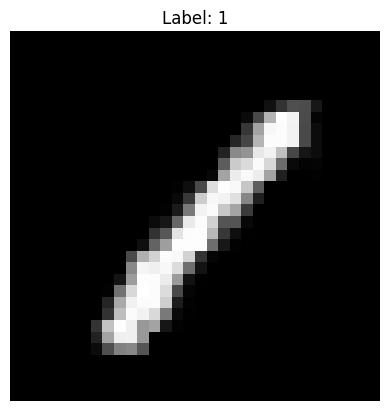

Label: 9
Tensor shape: torch.Size([1, 32, 32])


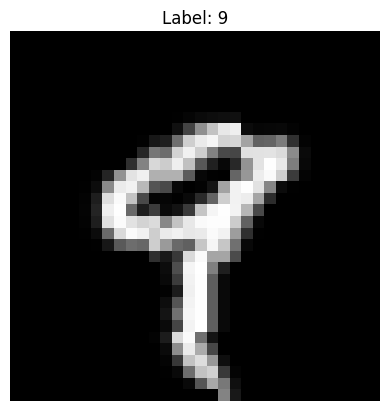

In [141]:
import matplotlib.pyplot as plt
import torchvision


for i in range(5):
  image, label = train_dataset[i]
  print("Label:", label)
  print("Tensor shape:", image.shape)

  plt.imshow(image.squeeze(), cmap='gray')
  plt.title(f"Label: {label}")
  plt.axis('off')
  plt.show()

In [142]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

In [143]:
train_dataset, val_dataset = train_test_split(train_dataset, test_size=0.1)

In [144]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=1, shuffle=True)

In [145]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr)

In [146]:
from tqdm import tqdm
import torch.nn.functional as F
for epoch in tqdm(range(epochs), position=0, leave=True):
  train_running_loss = 0
  correct_train = 0
  correct_val = 0
  total_train = 0
  total_val = 0
  best_val_acc = 0
  best_val_loss = 0
  patience = 3
  counter = 0
  model.train()
  for images, labels in train_dataloader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_running_loss += loss.item()

    probs = F.softmax(outputs, dim=1)
    predicted = torch.argmax(probs, dim=1)
    correct_train += (predicted == labels).sum().item()
    total_train += labels.size(0)

  train_acc = 100 * correct_train / total_train
  train_loss = train_running_loss / len(train_dataloader)

  model.eval()
  with torch.no_grad():
    val_running_loss = 0
    for images, labels in val_dataloader:
      images = images.to(device)
      labels = labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)
      val_running_loss += loss.item()

      probs = F.softmax(outputs, dim=1)
      predicted = torch.argmax(probs, dim=1)
      correct_val += (predicted == labels).sum().item()
      total_val += labels.size(0)

    val_acc = 100 * correct_val / total_val
    val_loss = val_running_loss / len(val_dataloader)
  print(f"\nEpoch {epoch+1}: Training Loss: {train_loss:.4f} Training acc: {train_acc: .4f} Validation Loss: {val_loss:.4f} Validation acc: {val_acc: .4f}")
  if val_acc > best_val_acc and val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), "best_lenet.pth")
  else:
        counter += 1
  if counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break
print("Training Complete!")


  2%|▎         | 1/40 [00:07<05:08,  7.91s/it]


Epoch 1: Training Loss: 1.9629 Training acc:  54.5778 Validation Loss: 1.6069 Validation acc:  73.2667


  5%|▌         | 2/40 [00:16<05:09,  8.14s/it]


Epoch 2: Training Loss: 1.3859 Training acc:  69.7889 Validation Loss: 1.1465 Validation acc:  78.4333


  8%|▊         | 3/40 [00:24<05:05,  8.27s/it]

...


Epoch 38: Training Loss: 0.2248 Training acc:  92.7759 Validation Loss: 0.1229 Validation acc:  96.6333


 98%|█████████▊| 39/40 [05:18<00:08,  8.10s/it]


Epoch 39: Training Loss: 0.2163 Training acc:  92.9111 Validation Loss: 0.1200 Validation acc:  96.6333


100%|██████████| 40/40 [05:26<00:00,  8.17s/it]


Epoch 40: Training Loss: 0.2139 Training acc:  93.0056 Validation Loss: 0.1171 Validation acc:  96.7333
Training Complete!


In [149]:
torch.save(model.state_dict(), '/content/model/lenet.pth')

In [150]:
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True)


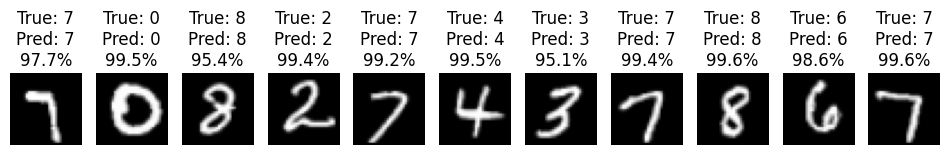

In [152]:
import matplotlib.pyplot as plt
import torch
import torchvision
model.eval()

images, labels = next(iter(test_dataloader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)
    predicted = torch.argmax(probs, dim=1)

num_display = 11

plt.figure(figsize=(12, 4))
for i in range(num_display):
    img = images[i].cpu().squeeze()
    true_label = labels[i].item()
    pred_label = predicted[i].item()
    prob = probs[i][pred_label].item()

    plt.subplot(1, num_display, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label}\nPred: {pred_label}\n{prob*100:.1f}%")
    plt.axis('off')
plt.show()

In [182]:
from huggingface_hub import HfApi

In [183]:
api = HfApi()

In [178]:
!rm -f ~/.huggingface/token

In [185]:
api.upload_file(
    path_or_fileobj="/content/model/lenet.pth",
    path_in_repo="lenet.pth",
    repo_id="maharjanabeeral/lenet-cnn",
    repo_type="model",
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/model/lenet.pth    : 100%|##########|  254kB /  254kB            

CommitInfo(commit_url='https://huggingface.co/maharjanabeeral/lenet-cnn/commit/cef28cbb8c61c514bcc52e990d4f613229785f59', commit_message='Upload lenet.pth with huggingface_hub', commit_description='', oid='cef28cbb8c61c514bcc52e990d4f613229785f59', pr_url=None, repo_url=RepoUrl('https://huggingface.co/maharjanabeeral/lenet-cnn', endpoint='https://huggingface.co', repo_type='model', repo_id='maharjanabeeral/lenet-cnn'), pr_revision=None, pr_num=None)